# WESM Price Prediction - Model 3: Neural Network

## Setup and Loading

In [439]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34535 entries, 0 to 34534
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            34535 non-null  datetime64[ns]
 1   GWAP                34535 non-null  float64       
 2   energy_demand_mw    34535 non-null  float64       
 3   energy_supply_mw    34535 non-null  float64       
 4   energy_shortage_mw  34535 non-null  float64       
 5   reserve_demand_mw   34535 non-null  float64       
 6   reserve_supply_mw   34535 non-null  float64       
 7   outage_count        34535 non-null  float64       
 8   GWAP_Lag_1          34535 non-null  float64       
 9   GWAP_Lag_12         34535 non-null  float64       
 10  GWAP_Lag_288        34535 non-null  float64       
 11  hour_sin            34535 non-null  float64       
 12  hour_cos            34535 non-null  float64       
 13  dow_1               34535 non-null  int64     

First we need to ensure consistency across all data types to be able to use Tensor later on. So, we will convert the `month_year` feature into a datetime variable and separate them into two categories: `month` and `year`.

In [440]:
# df["month_year"] = df["datetime"].dt.to_period("M").astype(str)

# # Convert string to datetime
# df['date_col'] = pd.to_datetime(df['month_year'], format='%Y-%m')

# df['year'] = df['date_col'].dt.year
# df['month'] = df['date_col'].dt.month

`X_gwap` will contain all the features aside from `GWAP` and `gwap_range` as those will serve as our label. Time-based columns are also dropped since we have already made separate columns for `year` and `month`. `y_gwap` will contain the **GWAP** and serve as our label.

In [441]:
# # remove datetime since we already have separate columns
# X_gwap = df.drop(["GWAP", "datetime", "month_year", "date_col", "energy_shortage_mw"], axis=1)

# # Transforms the class variable into a matrix of shape (n_samples, 1)
# y_gwap = df["GWAP"].values

# X_gwap.head()

In [442]:
# y_gwap

In [443]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "GWAP"

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of features: 16
Features: ['energy_demand_mw', 'energy_supply_mw', 'reserve_demand_mw', 'reserve_supply_mw', 'outage_count', 'GWAP_Lag_1', 'GWAP_Lag_12', 'GWAP_Lag_288', 'hour_sin', 'hour_cos', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


---

## Splitting the Data

Dividing the dataset into training set, validation set, and test set. The **test set** and **validation set** will contain 15% of the original dataset, while the **training set** will contain 70%.

In [444]:
# from sklearn.model_selection import train_test_split

# # Separate the test set from the train and validation sets
# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X_gwap,
#     y_gwap,
#     test_size=0.15,
#     random_state=1,
#     shuffle=True
# )

# # Separate the validation set from the train set
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_val,
#     y_train_val,
#     test_size=0.17647,  # 15% of leftover data
#     random_state=1,
#     shuffle=True
# )

In [445]:
# print("Size of training set: ", X_train.shape)
# print("Size of validation set: ", X_val.shape)
# print("Size of test set: ", X_test.shape)

In [446]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

print(f"Train : {len(train_df):>6} rows | {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):>6} rows | {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):>6} rows | {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

Train :  20721 rows | 2025-10-29 to 2026-01-08
Val   :   6907 rows | 2026-01-08 to 2026-02-01
Test  :   6907 rows | 2026-02-01 to 2026-02-26


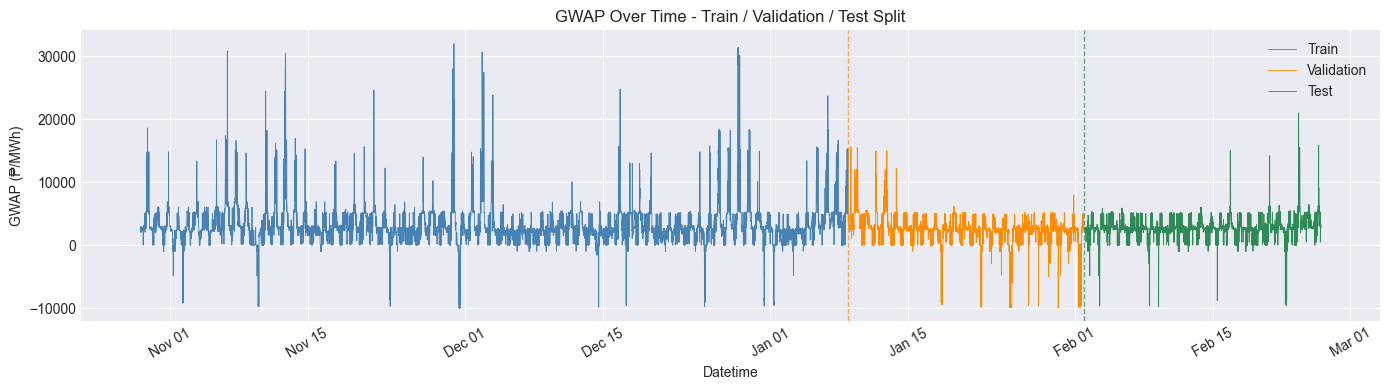

In [447]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train_df["datetime"], train_df["GWAP"], color="steelblue",  label="Train",      linewidth=0.6)
ax.plot(val_df["datetime"],   val_df["GWAP"],   color="darkorange", label="Validation", linewidth=0.6)
ax.plot(test_df["datetime"],  test_df["GWAP"],  color="seagreen",   label="Test",       linewidth=0.6)

ax.axvline(train_df["datetime"].max(), color="darkorange", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(val_df["datetime"].max(),   color="seagreen",   linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("GWAP Over Time - Train / Validation / Test Split")
ax.set_xlabel("Datetime")
ax.set_ylabel("GWAP (₱/MWh)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [448]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

---

## Standardizing the Data

Since we are working with high-magnitude values, we will standardize our data to lessen the probability of overshooting. We will only fit on training data to prevent data leakage.

In [449]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)

# fit on training data only to prevent data leakage (happens when using test data to compute mean/std)
X_test = scaler_X.transform(X_test)
X_val = scaler_X.transform(X_val)  

In [450]:
scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# fit on training data only to prevent data leakage (happens when using test data to compute mean/std)
y_test = scaler_y.transform(y_test.values.reshape(-1, 1))
y_val = scaler_y.transform(y_val.values.reshape(-1, 1))

---

## Converting to Tensor

Convert the np.ndarrays to datatype torch.Tensor

In [451]:
X_train = torch.Tensor(X_train)
y_train = torch.Tensor(y_train)
X_test = torch.Tensor(X_test)
y_test = torch.Tensor(y_test)
X_val = torch.Tensor(X_val)
y_val = torch.Tensor(y_val)

---

## Setting up the Neural Network

*Hyperparameter tuning to be done later, this is just to see how it works with a random model

First, we import the NeuralNetwork class

In [452]:
from neural_network import NeuralNetwork

The model we will use will have the following parameters:
- `input_size`: 11 features
- `hidden_layers`: [64, 32]
- `output_size`: 1
- `activation`: relu

We are creating a Neural Network that takes in **11 features** with **2 hidden layers**, where there are **64 neurons** in the first hidden layer and **32 neurons** in the second hidden layer.

Since we are using **regression**, there will only be 1 output neuron. The activation function we will use for the hidden layers is **reLu**.

In [453]:
input_size = X_train.shape[1]  # 11 features
hidden_layers = [64, 32]      # to be tuned
output_size = 1

model = NeuralNetwork(
    input_size=input_size, 
    num_outputs=output_size,
    list_hidden=hidden_layers,
    activation='relu')

We then create the network and initialize the weights

In [454]:
model.create_network()
model.init_weights()
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


---

## Setting the Loss Function and Optimizer

This model will use **MSE** for evaluation and **Adam** as the optimizer with a learning rate of **0.001**.

In [455]:
# used for regression
criterion = nn.HuberLoss()  
learning_rate = 0.001      
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

---

## Training

The training pipeline follows the typical progression of a neural network.

1. Empty the gradients of the network.
2. Forward propagation
3. Compute the loss
4. Backward propagation
5. Update parameters

We will use mini-batch gradient descent to train our model. We will use our Dataloader object to handle batch segragation and pass **32** as our batch size.

In [456]:
from data_laoder import DataLoader

batch_size = 32  # to be tuned
data_loader = DataLoader(X_train, y_train, batch_size)

We will have a maximum epoch of **400**. We will also check if the values are converging, determined if the difference in loss of each epoch is less than **0.00005**

`Note`: `model(X)` is called instead of `model.forward` since it automatically calls the forward method with gradient tracking, hooks, distributed training support, and mixed precision support.

In [457]:
epoch = 0
max_epochs = 400
is_converged = False
previous_loss = 0
losses = []

# For each epoch
while epoch <= max_epochs and is_converged is not True:
    
    current_epoch_loss = 0
    
    # Get the batch for this epoch.
    X_batch, y_batch = data_loader.get_batch()
    
    # For each batch
    for X, y in zip(X_batch, y_batch):
        X = torch.Tensor(X)
        # y = torch.Tensor(y).to(torch.long)
        y = torch.Tensor(y)
        
        model.train()

        # Empty the gradients of the network.
        optimizer.zero_grad()
        
        # Forward propagation
        y_pred = model(X) # calls the forward method but adding gradient tracking, hooks, extra support
        
        # Compute the loss
        loss = criterion(y_pred, y)
        
        # Backward propagation
        loss.backward()

        # Update parameters
        optimizer.step()
        
        current_epoch_loss += loss.item()
    
    average_loss = current_epoch_loss / len(X_batch)
    losses.append(average_loss)
    
    # Display the average loss per epoch
    if epoch % 20 == 0:
        print('Epoch:', epoch, '\tLoss: {:.6f}'.format(average_loss))
    
    if abs(previous_loss - loss) < 0.00005:
        is_converged = True
    else:
        previous_loss = loss
        epoch += 1

Epoch: 0 	Loss: 0.083699
Epoch: 20 	Loss: 0.056696
Epoch: 40 	Loss: 0.053574
Epoch: 60 	Loss: 0.051764
Epoch: 80 	Loss: 0.049777
Epoch: 100 	Loss: 0.048276
Epoch: 120 	Loss: 0.047409
Epoch: 140 	Loss: 0.046379
Epoch: 160 	Loss: 0.045251
Epoch: 180 	Loss: 0.044601
Epoch: 200 	Loss: 0.043724
Epoch: 220 	Loss: 0.042675
Epoch: 240 	Loss: 0.042369
Epoch: 260 	Loss: 0.041803
Epoch: 280 	Loss: 0.041405
Epoch: 300 	Loss: 0.040942
Epoch: 320 	Loss: 0.040542
Epoch: 340 	Loss: 0.040234
Epoch: 360 	Loss: 0.039867
Epoch: 380 	Loss: 0.039422
Epoch: 400 	Loss: 0.039076


In [458]:
#epochs = 201   # to be tuned
#train_losses = []
#val_losses = []
#is_converged = False
#
## TODO: implement mini-batch gradient descent and convergence check
#for epoch in range(epochs):
#    model.train()
#
#    # Empty the gradients of the network.
#    optimizer.zero_grad()
#    
#    # Forward propagation
#    y_pred = model(X_train) # calls the forward method but adding gradient tracking, hooks, extra support
#    
#    # Compute the loss
#    loss = criterion(y_pred, y_train)
#    
#    # Backward propagation
#    loss.backward()
#
#    # Update parameters
#    optimizer.step()
#    
#    # Validation
#    model.eval()
#    with torch.no_grad():
#        y_val_pred = model(X_val)
#        val_loss = criterion(y_val_pred, y_val)
#
#    train_losses.append(loss.item())
#    val_losses.append(val_loss.item())
#    
#    if epoch % 20 == 0:
#        print(f"Epoch {epoch}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

### Loss for Each Epoch 

Text(0.5, 1.0, 'Loss for each epoch')

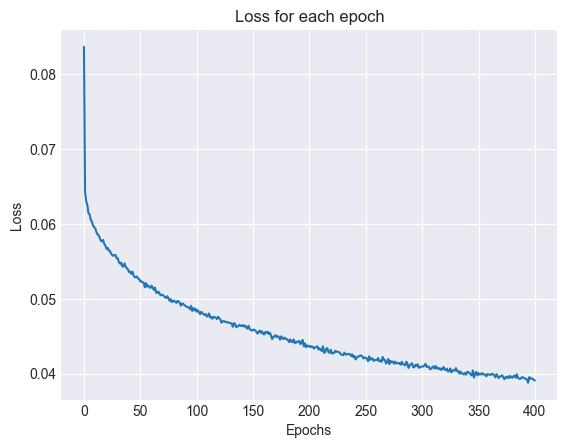

In [459]:
x_values = [i for i in range(len(losses))]
y_values = losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss for each epoch')

---

## Evaluating on Test Data

We will now test the performance of our model on the **Test set**. 

`Notes`:
- We use `torch.no_grad`, which disables gradient calculation, since we will **not** be doing backwards propagation when evaluating on the test set.
- Since we standardized our data earlier, we use `scaler_y.inverse_transform` to return the values to its original scale.

In [460]:
# model.eval()
# with torch.no_grad():
#     y_pred_test = model(X_test)

# # inverse-transform the predictions to get them back to the original scale
# y_pred_original = scaler_y.inverse_transform(y_pred_test.numpy())
# y_test_original = scaler_y.inverse_transform(y_test.numpy())

In [461]:
# y_pred_original = scaler_y.inverse_transform(y_pred_test.detach().numpy())
# y_test_original = scaler_y.inverse_transform(y_test.detach().numpy())

# mae_real = np.mean(np.abs(y_pred_original - y_test_original))
# print(mae_real)

In [462]:
# test_loss = criterion(y_pred_test, y_test)
# print(test_loss)

In [463]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, X, y, label):
    model.eval()
    with torch.no_grad():
        y_pred = model(X)
    
    y_pred_np = y_pred.detach().numpy()
    y_np = y.detach().numpy()
    
    rmse = np.sqrt(mean_squared_error(y_np, y_pred_np))
    mae  = mean_absolute_error(y_np, y_pred_np)
    r2   = r2_score(y_np, y_pred_np)
    print(f"{label:<12} | RMSE: {rmse:>12.4f} | MAE: {mae:>10.4f} | R²: {r2:>8.4f}")
    return y_pred_np, rmse, mae, r2

print(f"{'Split':<12} | {'RMSE':>18} | {'MAE':>14} | {'R\u00b2':>12}")
print("-" * 68)

# lr evaluated on its own training data
y_train_pred, train_rmse, train_mae, train_r2 = evaluate(model, X_train, y_train, "Train")

# lr evaluated on validation (unseen to lr)  
y_val_pred, val_rmse, val_mae, val_r2 = evaluate(model, X_val, y_val, "Validation")

# lr_final evaluated on its own training data (train+val combined)
# y_trainval_pred, trainval_rmse, _, _ = evaluate(lr_final, X_trainval, y_trainval, "Train+Val")

# lr_final evaluated on test (unseen to lr_final)
y_test_pred, test_rmse, test_mae, test_r2 = evaluate(model, X_test, y_test, "Test")

Split        |               RMSE |            MAE |           R²
--------------------------------------------------------------------
Train        | RMSE:       0.3133 | MAE:     0.1616 | R²:   0.9018
Validation   | RMSE:       0.6625 | MAE:     0.3706 | R²:   0.3684
Test         | RMSE:       0.5001 | MAE:     0.3484 | R²:   0.1984


### Visualization

Now, let us compare the model's predictions against the actual values using a scatter plot.

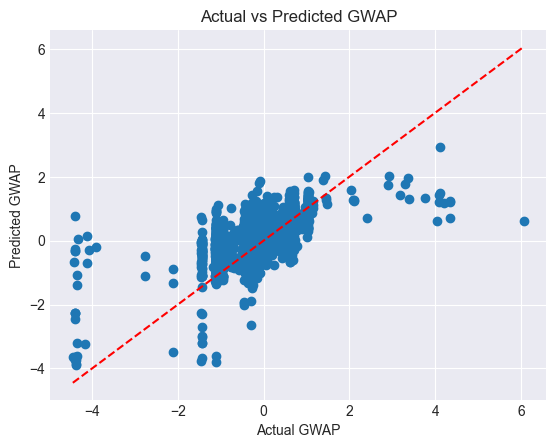

In [464]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual GWAP")
plt.ylabel("Predicted GWAP")
plt.title("Actual vs Predicted GWAP")
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         'r--')  # perfect prediction line
plt.show()

*analysis and conclusion to be added

---

## Hyperparameter Tuning

Our current lowest loss is **0.0916** after training on 400 epochs. We will implement hyperparameter tuning on the following parameters in an attempt to better our current model.

Selected parameters to be tuned:

- hidden_layers = [[32], [64], [128], [32,32], [64,64], [128,128], [32, 32, 32], [64, 64, 64]]
- learning_rates = [0.01, 0.001]
- batch_sizes = [32, 64]
- activation = ['relu', 'tanh']

In [465]:
hidden_layers = [[32], [64], [128], [32,32], [64,64], [128,128], [32, 32, 32], [64, 64, 64], [128, 128, 128]]
learning_rates = [0.01, 0.001]
batch_sizes = [32, 64, 128]
activation = ['relu', 'tanh']

In [466]:
def train_and_evaluate(model, optimizer, batch_size):

    criterion = nn.HuberLoss()

    # Validation evaluation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    return val_loss.item()

In [467]:
results = []
best_loss = float('inf')
best_params = None
input_size = X_train.shape[1]

for hidden in hidden_layers:
    for lr in learning_rates:
        for batch in batch_sizes:
            for act in activation:

                print(f"Testing: layers={hidden}, lr={lr}, batch={batch}, act={act}")

                model = NeuralNetwork(
                    input_size=input_size,
                    num_outputs=1,
                    list_hidden=hidden,
                    activation=act
                )

                model.create_network()
                model.init_weights()

                optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                val_loss = train_and_evaluate(model, optimizer, batch)

                print(f"Validation Loss: {val_loss:.4f}")

                results.append({
                    "hidden_layers": hidden,
                    "learning_rate": lr,
                    "batch_size": batch,
                    "activation": act,
                    "val_loss": val_loss
                })

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_params = results[-1]

print("Best Parameters:")
print(best_params)

Testing: layers=[32], lr=0.01, batch=32, act=relu
Validation Loss: 0.3012
Testing: layers=[32], lr=0.01, batch=32, act=tanh
Validation Loss: 0.2118
Testing: layers=[32], lr=0.01, batch=64, act=relu
Validation Loss: 0.3012
Testing: layers=[32], lr=0.01, batch=64, act=tanh
Validation Loss: 0.2118
Testing: layers=[32], lr=0.01, batch=128, act=relu
Validation Loss: 0.3012
Testing: layers=[32], lr=0.01, batch=128, act=tanh
Validation Loss: 0.2118
Testing: layers=[32], lr=0.001, batch=32, act=relu
Validation Loss: 0.3012
Testing: layers=[32], lr=0.001, batch=32, act=tanh
Validation Loss: 0.2118
Testing: layers=[32], lr=0.001, batch=64, act=relu
Validation Loss: 0.3012
Testing: layers=[32], lr=0.001, batch=64, act=tanh
Validation Loss: 0.2118
Testing: layers=[32], lr=0.001, batch=128, act=relu
Validation Loss: 0.3012
Testing: layers=[32], lr=0.001, batch=128, act=tanh
Validation Loss: 0.2118
Testing: layers=[64], lr=0.01, batch=32, act=relu
Validation Loss: 0.2823
Testing: layers=[64], lr=0.0

---

## Updating the Model

In [468]:
input_size = X_train.shape[1]  # 11 features
hidden_layers = [32]     
output_size = 1
activation = 'tanh'

model = NeuralNetwork(
    input_size=input_size, 
    num_outputs=output_size,
    list_hidden=hidden_layers,
    activation=activation)

In [469]:
model.create_network()
model.init_weights()
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [470]:
# used for regression
criterion = nn.HuberLoss()  
learning_rate = 0.01      
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [471]:
from data_laoder import DataLoader

batch_size = 32 
data_loader = DataLoader(X_train, y_train, batch_size)

In [472]:
epoch = 0
max_epochs = 400
is_converged = False
previous_loss = 0
losses = []

# For each epoch
while epoch <= max_epochs and is_converged is not True:
    
    current_epoch_loss = 0
    
    # Get the batch for this epoch.
    X_batch, y_batch = data_loader.get_batch()
    
    # For each batch
    for X, y in zip(X_batch, y_batch):
        X = torch.Tensor(X)
        # y = torch.Tensor(y).to(torch.long)
        y = torch.Tensor(y)
        
        model.train()

        # Empty the gradients of the network.
        optimizer.zero_grad()
        
        # Forward propagation
        y_pred = model(X) # calls the forward method but adding gradient tracking, hooks, extra support
        
        # Compute the loss
        loss = criterion(y_pred, y)
        
        # Backward propagation
        loss.backward()

        # Update parameters
        optimizer.step()
        
        current_epoch_loss += loss.item()
    
    average_loss = current_epoch_loss / len(X_batch)
    losses.append(average_loss)
    
    # Display the average loss per epoch
    if epoch % 20 == 0:
        print('Epoch:', epoch, '\tLoss: {:.6f}'.format(average_loss))
    
    if abs(previous_loss - loss) < 0.00005:
        is_converged = True
    else:
        previous_loss = loss
        epoch += 1

Epoch: 0 	Loss: 0.082487
Epoch: 20 	Loss: 0.065509
Epoch: 40 	Loss: 0.064472
Epoch: 60 	Loss: 0.064054


Text(0.5, 1.0, 'Loss for each epoch')

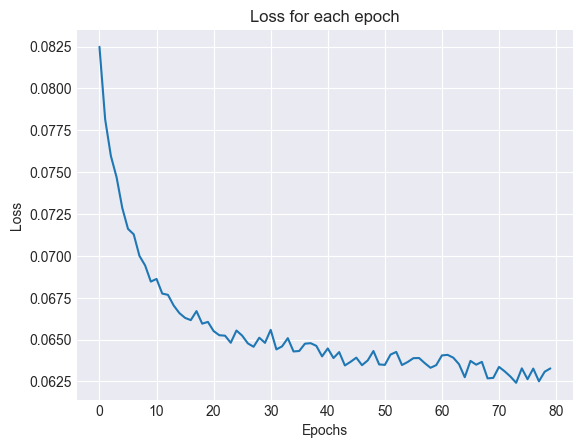

In [473]:
x_values = [i for i in range(len(losses))]
y_values = losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss for each epoch')

In [474]:
# model.eval()
# with torch.no_grad():
#     y_pred_test = model(X_test)

# # inverse-transform the predictions to get them back to the original scale
# y_pred_original = scaler_y.inverse_transform(y_pred_test.numpy())
# y_test_original = scaler_y.inverse_transform(y_test.numpy())

In [475]:
# y_pred_original = scaler_y.inverse_transform(y_pred_test.detach().numpy())
# y_test_original = scaler_y.inverse_transform(y_test.detach().numpy())

# mae_real = np.mean(np.abs(y_pred_original - y_test_original))
# print(mae_real)

In [476]:
# test_loss = criterion(y_pred_test, y_test)
# print(test_loss)

In [477]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, X, y, label):
    model.eval()
    with torch.no_grad():
        y_pred = model(X)
    
    y_pred_np = y_pred.detach().numpy()
    y_np = y.detach().numpy()
    
    rmse = np.sqrt(mean_squared_error(y_np, y_pred_np))
    mae  = mean_absolute_error(y_np, y_pred_np)
    r2   = r2_score(y_np, y_pred_np)
    print(f"{label:<12} | RMSE: {rmse:>12.4f} | MAE: {mae:>10.4f} | R²: {r2:>8.4f}")
    return y_pred_np, rmse, mae, r2

print(f"{'Split':<12} | {'RMSE':>18} | {'MAE':>14} | {'R\u00b2':>12}")
print("-" * 68)

# lr evaluated on its own training data
y_train_pred, train_rmse, train_mae, train_r2 = evaluate(model, X_train, y_train, "Train")

# lr evaluated on validation (unseen to lr)  
y_val_pred, val_rmse, val_mae, val_r2 = evaluate(model, X_val, y_val, "Validation")

# lr_final evaluated on its own training data (train+val combined)
# y_trainval_pred, trainval_rmse, _, _ = evaluate(lr_final, X_trainval, y_trainval, "Train+Val")

# lr_final evaluated on test (unseen to lr_final)
y_test_pred, test_rmse, test_mae, test_r2 = evaluate(model, X_test, y_test, "Test")

Split        |               RMSE |            MAE |           R²
--------------------------------------------------------------------
Train        | RMSE:       0.4074 | MAE:     0.2129 | R²:   0.8341
Validation   | RMSE:       0.4038 | MAE:     0.2272 | R²:   0.7654
Test         | RMSE:       0.3856 | MAE:     0.2470 | R²:   0.5235


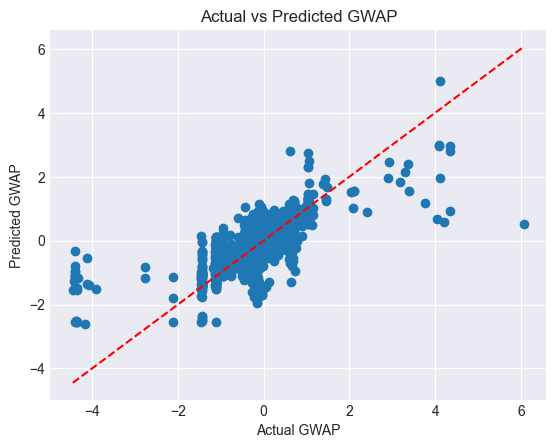

In [478]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual GWAP")
plt.ylabel("Predicted GWAP")
plt.title("Actual vs Predicted GWAP")
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         'r--')  # perfect prediction line
plt.show()